# Image Classifier for the SVHN Dataset

*Multi-layer perceptron and convolutional neural network built with TensorFlow 2 / Keras, trained to read house-number digits from real-world street photos.*

The goal of this project is to go through a complete image classification workflow: load and preprocess a dataset harder than MNIST, build two different classifiers, train them, track their learning curves, evaluate them on unseen data, save the best weights and compare their predictions side by side.

## 1. Libraries and setup

TensorFlow builds and trains both models, NumPy and Matplotlib handle the arrays and the plots, and `scipy.io.loadmat` reads the `.mat` files the SVHN dataset is distributed in.

In [1]:
# TensorFlow for the models, loadmat to read the .mat dataset files
import tensorflow as tf
from scipy.io import loadmat

## 2. The SVHN dataset

![Sample of SVHN house-number digits](data/svhn_examples.jpg)

The [Street View House Numbers (SVHN)](http://ufldl.stanford.edu/housenumbers/) dataset is used. It contains over 600,000 digit images and is harder than MNIST because the digits appear in the context of real, cluttered scenes: house numbers cropped from Google Street View photos.

* Y. Netzer, T. Wang, A. Coates, A. Bissacco, B. Wu and A. Y. Ng. "Reading Digits in Natural Images with Unsupervised Feature Learning". NIPS Workshop on Deep Learning and Unsupervised Feature Learning, 2011.

The goal is to build an end-to-end workflow for building, training, validating, evaluating and saving a neural network that classifies each image into one of ten digit classes (0-9).

## 3. Load the data

The dataset ships as two `.mat` files, `train_32x32.mat` and `test_32x32.mat`, loaded with `scipy.io.loadmat`.

In [2]:
# Both files load as dictionaries with the images and labels inside
train = loadmat('data/train_32x32.mat')
test = loadmat('data/test_32x32.mat')

Both `train` and `test` are dictionaries with two keys: `X` for the images and `y` for the labels.

In [3]:
# Raw pixel values, uint8, shape (32, 32, 3, num_images)
train['X']

array([[[[ 33,  84,  19, ...,  92, 190, 216],
         [ 30,  76,  54, ...,  78, 188, 217],
         [ 38,  59, 110, ..., 101, 191, 212]],

        [[ 15,  86,  20, ...,  94, 205, 221],
         [ 23,  73,  52, ...,  82, 203, 222],
         [ 19,  66, 111, ..., 105, 206, 217]],

        [[ 15,  77,  25, ..., 114, 220, 226],
         [ 17,  78,  57, ..., 101, 218, 227],
         [ 19,  56, 116, ..., 125, 220, 221]],

        ...,

        [[ 72,  90,  65, ..., 200, 229, 200],
         [ 65,  78, 144, ..., 201, 231, 199],
         [ 56,  69, 223, ..., 203, 224, 191]],

        [[ 82,  88,  78, ..., 192, 229, 193],
         [ 77,  77, 148, ..., 193, 229, 188],
         [ 57,  67, 218, ..., 195, 224, 182]],

        [[ 89,  88,  98, ..., 190, 229, 197],
         [ 79,  78, 158, ..., 191, 228, 189],
         [ 59,  66, 220, ..., 193, 223, 186]]],


       [[[ 28,  85,  21, ...,  92, 183, 204],
         [ 39,  77,  53, ...,  78, 182, 205],
         [ 35,  61, 110, ..., 103, 186, 202]],

    

As shown above, the training set has 73,257 images. `train['X']` is a 4D array with shape `(32, 32, 3, 73257)`: each image is 32x32 pixels with three colour channels (red, green, blue), and the last axis indexes the images instead of being the first one as usual — that gets fixed in the next section.

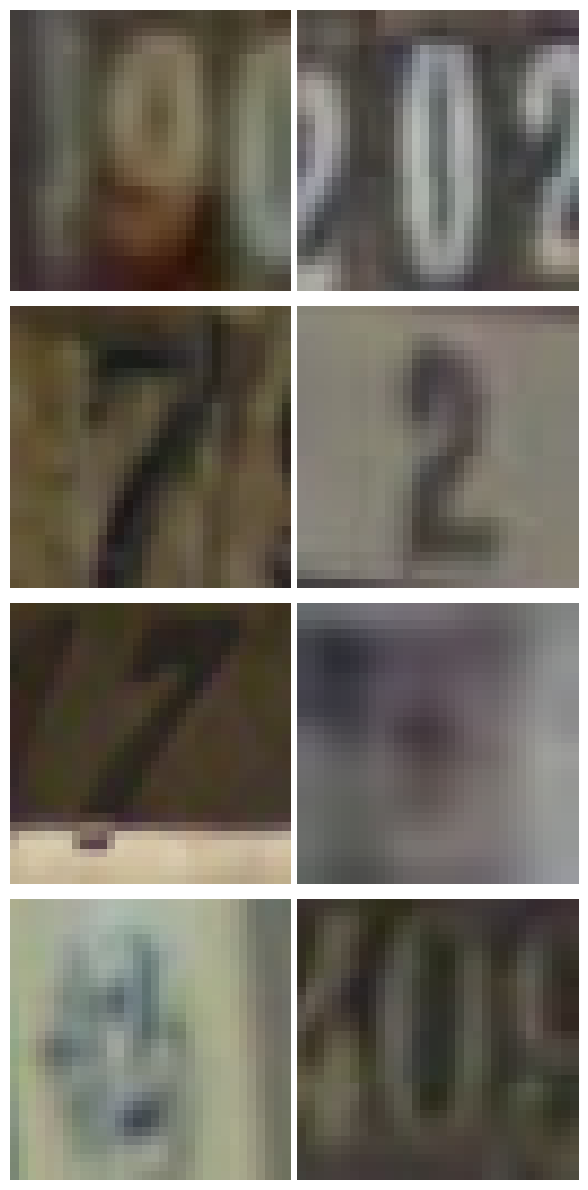

In [4]:
# Quick peek at eight random raw images, before splitting out the labels
import numpy as np
import matplotlib.pyplot as plt

num_samples = train['X'].shape[-1]
idx = np.random.choice(num_samples, size=8, replace=False)

fig, axes = plt.subplots(4, 2, figsize=(6, 12))

for i, ax in enumerate(axes.flat):
    image = train['X'][:, :, :, idx[i]]
    
    ax.imshow(image)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Prepare the training and test arrays

The raw dictionaries are split into `X`/`y` arrays, visualised with their labels and converted to grayscale before they are fed to a model.

### 4.1 Split images and labels

Extracting the training and test images and labels separately from the loaded dictionaries.

In [5]:
# Pull the images and labels out of the loaded dictionaries
X_train = train['X']
y_train = train['y']

X_test = test['X']
y_test = test['y']

### 4.2 Visual inspection with labels

A random sample of images together with the digit each label represents.

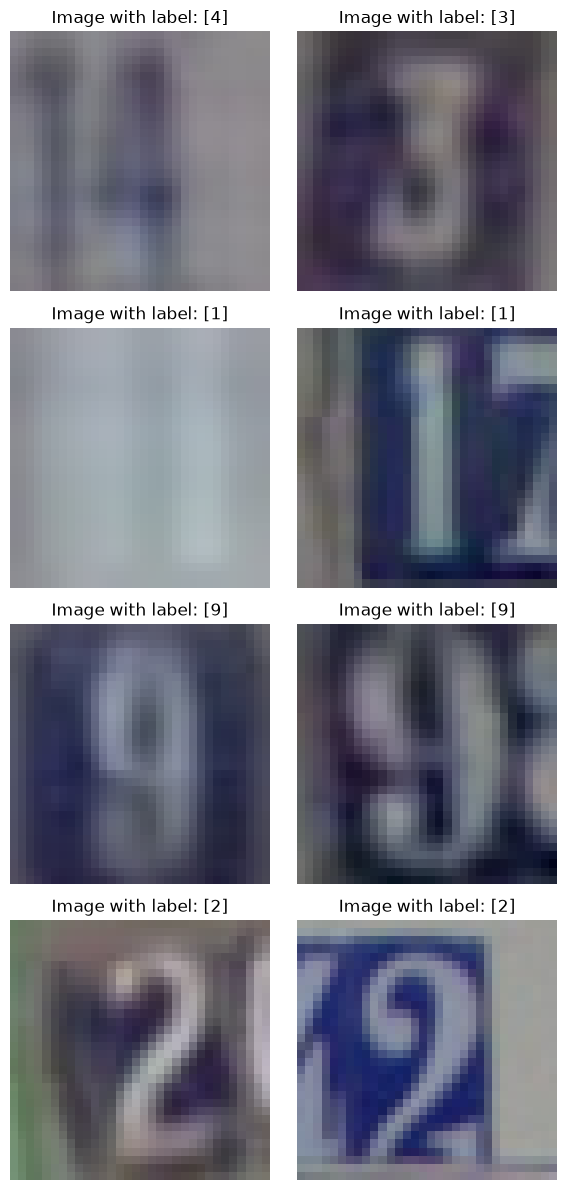

In [6]:
# Random sample of images with their label overlaid as the title
import numpy as np
import matplotlib.pyplot as plt

num_samples = X_train.shape[-1]
idx = np.random.choice(num_samples, size=8, replace=False)

fig, axes = plt.subplots(4, 2, figsize=(6, 12))

for i, ax in enumerate(axes.flat):
    image = X_train[:, :, :, idx[i]]
    ax.set_title(f"Image with label: {y_train[idx[i]]}")
    ax.imshow(image)
    ax.axis("off")

plt.tight_layout()
plt.show()

### 4.3 Convert to grayscale

Colour is not essential to recognise a digit, so the three channels are averaged into one to shrink the input size. The resulting shape is `(32, 32, 1, N)`.

In [7]:
# Average the RGB channels together into a single grayscale channel
X_train_gray = np.mean(X_train, axis=2, keepdims=True)
X_test_gray = np.mean(X_test, axis=2, keepdims=True)

print("X_train_gray shape:", X_train_gray.shape)
print("X_test_gray shape:", X_test_gray.shape)

X_train_gray shape: (32, 32, 1, 73257)
X_test_gray shape: (32, 32, 1, 26032)


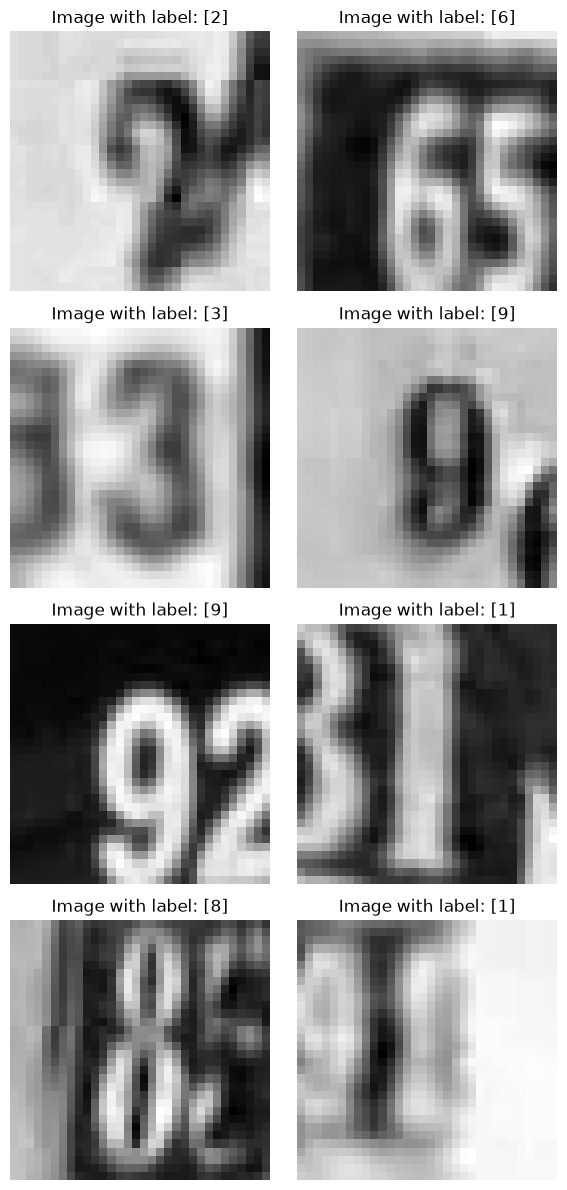

In [8]:
# Same random sample, now in grayscale
num_samples = X_train_gray.shape[-1]
idx = np.random.choice(num_samples, size=8, replace=False)

fig, axes = plt.subplots(4, 2, figsize=(6, 12))

for i, ax in enumerate(axes.flat):
    image = X_train_gray[:, :, :, idx[i]]
    ax.set_title(f"Image with label: {y_train[idx[i]]}")
    ax.imshow(image, cmap='gray')
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Baseline MLP classifier

A multilayer perceptron is trained first as a baseline. Before that, the grayscale arrays are reshaped to put the image index first (`(N, 32, 32, 1)`, the format Keras expects) and normalised to `[0, 1]`; the same arrays are reused later for the CNN.

In [9]:
# Move the image axis first and scale pixel values to [0, 1]
X_train_gray = np.transpose(X_train_gray, (3,0,1,2))

X_test_gray = np.transpose(X_test_gray, (3,0,1,2))

X_train_gray = X_train_gray/255.0
X_test_gray = X_test_gray/255.0

### 5.1 Build the network

A `Sequential` stack of five dense blocks (512 → 256 → 256 → 128 → 128 units), each with `he_normal` initialisation and batch normalisation to keep training stable; the three largest layers also get a light L2 penalty to curb overfitting on a fully-connected model this deep.

In [10]:
# Fully-connected baseline: five dense blocks with batch norm and light L2 regularization
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, Flatten, BatchNormalization, Dropout
from tensorflow.keras.regularizers import l2

model_mlp = Sequential([
    Flatten(input_shape=(32,32,1)),
    Dense(512, activation='relu',
          kernel_regularizer=l2(1e-4),
          kernel_initializer='he_normal'),
    BatchNormalization(),
    Dense(256, activation='relu',
          kernel_regularizer=l2(1e-4),
          kernel_initializer='he_normal'),
    BatchNormalization(),
    Dense(256, activation='relu',
          kernel_regularizer=l2(1e-4),
          kernel_initializer='he_normal'),
    BatchNormalization(),
    Dense(128, activation='relu',kernel_initializer='he_normal'),
    BatchNormalization(),
    Dense(128, activation='relu',
          kernel_initializer='he_normal'),
    BatchNormalization(),
    Dense(10, activation='softmax')
])

c:\Users\ramir\OneDrive\Documents\ESTUDIO\DEEP LEARNING\Tensorflow 2 for Deep Learning\1 - Getting started with TensorFlow 2\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
model_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 777,738 (2.97 MB)

 Trainable params: 775,178 (2.96 MB)

 Non-trainable params: 2,560 (10.00 KB)

The model has **775,178 trainable parameters** out of 777,738 total (the remaining 2,560 are batch-norm running statistics), most of them in the first dense layer that receives the flattened 1,024-pixel image.

In [12]:
# Adam with a conservative learning rate, since the network is deep and fully-connected
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0001)

model_mlp.compile(optimizer=optimizer, metrics=['accuracy'],
              loss='sparse_categorical_crossentropy')

### 5.2 Callbacks

Three callbacks keep training in check: `ModelCheckpoint` saves the best weights by validation loss, `EarlyStopping` stops training if it stalls for 10 epochs, and `ReduceLROnPlateau` shrinks the learning rate when validation loss plateaus.

In [13]:
# Save the best weights, stop early on a plateau, and decay the learning rate on stagnation
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

path = 'checkpoint_MLP/MLP_checkpoint.weights.h5'

checkpoint = ModelCheckpoint(
    save_weights_only=True,
    save_best_only=True,
    filepath=path,
    monitor='val_loss',
    verbose=1
)


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    patience=2,
    factor=0.3,
    min_lr=1e-6,
    verbose=1
)


callbacks_mlp = [checkpoint, early_stopping, reduce_lr]

### 5.3 Train the model

Labels use `10` for the digit `0` (a MATLAB convention), so they are remapped to `0` first. The model trains for up to 30 epochs with a 15% validation split, batch size 128.

In [14]:
# SVHN labels use 10 for the digit 0 (MATLAB 1-indexing); remap it to 0
y_train[y_train == 10] = 0
y_test[y_test == 10] = 0

history_mlp = model_mlp.fit(
    X_train_gray, 
    y_train,
    epochs = 30,
    batch_size=128,
    validation_split = 0.15,
    callbacks=callbacks_mlp,
    verbose=1
)

Epoch 1/30
484/487 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3971 - loss: 2.0358
Epoch 1: val_loss improved from None to 1.74630, saving model to checkpoint_MLP/MLP_checkpoint.weights.h5

Epoch 1: finished saving model to checkpoint_MLP/MLP_checkpoint.weights.h5
487/487 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3980 - loss: 2.0331 - val_accuracy: 0.4986 - val_loss: 1.7463 - learning_rate: 1.0000e-04
Epoch 2/30
487/487 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6397 - loss: 1.3337
Epoch 2: val_loss improved from 1.74630 to 1.36236, saving model to checkpoint_MLP/MLP_checkpoint.weights.h5

Epoch 2: finished saving model to checkpoint_MLP/MLP_checkpoint.weights.h5
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6397 - loss: 1.3337 - val_accuracy: 0.6314 - val_loss: 1.3624 - learning_rate: 1.0000e-04
Epoch 3/30
485/487 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7034 - loss: 1.1354
Epoch 3: val_loss improved from 1.36236 to 1.26146, saving model to checkpoint_MLP/ML

### 5.4 Learning curves

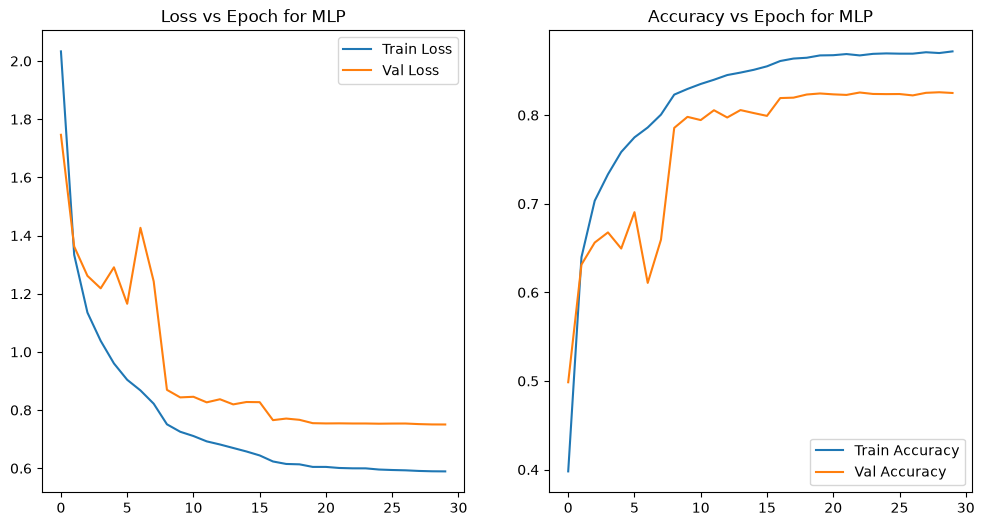

In [15]:
# Training vs validation, side by side for loss and accuracy
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,6))

ax1.plot(history_mlp.history['loss'], label='Train Loss')
ax1.plot(history_mlp.history['val_loss'], label='Val Loss')
ax1.set_title('Loss vs Epoch for MLP')
ax1.legend()

ax2.plot(history_mlp.history['accuracy'], label='Train Accuracy')
ax2.plot(history_mlp.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Accuracy vs Epoch for MLP')
ax2.legend()


plt.show()

### 5.5 Evaluate on the test set

In [16]:
# Performance on the 26,032 test images
test_loss, test_acc = model_mlp.evaluate(X_test_gray, y_test, verbose=0)
print(f"Test Loss for MLP Model: {test_loss:.4f}")
print(f"Test Accuracy for MLP Model: {test_acc:.4f}")

Test Loss for MLP Model: 0.8478
Test Accuracy for MLP Model: 0.8006


The MLP reaches **80.06% accuracy** on the test set (loss 0.8478), well below its 87% training accuracy — the fully-connected architecture struggles to generalise on images this cluttered, which motivates trying a convolutional network next.

## 6. Convolutional neural network (CNN) classifier

A small CNN is trained next to see whether convolutional filters, which exploit the 2D structure of the image, generalise better than the fully-connected MLP above.

### 6.1 Build the network

Two convolutional blocks (32 then 16 filters, each followed by 2x2 max pooling) extract spatial features before a small dense head (128 → 128 units) with batch normalisation and dropout classifies them.

In [17]:
# Two conv blocks for feature extraction, then a small dense head
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (Dense, Flatten, BatchNormalization, Dropout,
                                     Conv2D, MaxPool2D)
from tensorflow.keras.regularizers import l2

model_cnn = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu',
           input_shape=(32,32,1)),
    MaxPool2D((2,2)),
    Conv2D(16, (2,2), padding='same', activation='relu'),
    MaxPool2D((2,2)),
    Flatten(),
    Dense(128, activation='relu',kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu',
              kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

c:\Users\ramir\OneDrive\Documents\ESTUDIO\DEEP LEARNING\Tensorflow 2 for Deep Learning\1 - Getting started with TensorFlow 2\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 16)     │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,410 (595.35 KB)

 Trainable params: 151,898 (593.35 KB)

 Non-trainable params: 512 (2.00 KB)

With **151,898 trainable parameters**, the CNN is about a fifth the size of the MLP above, since the convolutional filters are shared across the whole image instead of connecting to every pixel individually.

In [19]:
# Higher learning rate than the MLP: convolutions converge faster here
from tensorflow.keras.optimizers import Adam

optimizer= Adam(learning_rate=0.001)

model_cnn.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

### 6.2 Callbacks

Same strategy as the MLP: checkpoint the best weights, stop early, and decay the learning rate on a plateau.

In [20]:
# Same callback strategy as the MLP, pointed at the CNN's own checkpoint path
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


early_stopping_cnn = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

path = 'checkpoint_CNN/CNN_checkpoint.weights.h5'

checkpoint_cnn = ModelCheckpoint(
    filepath=path,
    save_weights_only=True,
    save_best_only=True,
    verbose=1,
    monitor='val_loss'
)

reduce_lr_cnn = ReduceLROnPlateau(
    patience=2,
    factor=0.3,
    monitor='val_loss',
    min_lr=1e-6,
    verbose=1
)


callbacks_cnn = [early_stopping_cnn, checkpoint_cnn, reduce_lr_cnn]

### 6.3 Train the model

30 epochs, same batch size and validation split as the MLP, so the two models are compared under the same conditions.

In [21]:
# Labels were already remapped (10 -> 0) when training the MLP above
history_cnn = model_cnn.fit(
    X_train_gray, 
    y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.15,
    callbacks=callbacks_cnn,
    verbose=1
)

Epoch 1/30
486/487 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4740 - loss: 1.6007
Epoch 1: val_loss improved from None to 1.39747, saving model to checkpoint_CNN/CNN_checkpoint.weights.h5

Epoch 1: finished saving model to checkpoint_CNN/CNN_checkpoint.weights.h5
487/487 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4743 - loss: 1.6001 - val_accuracy: 0.5446 - val_loss: 1.3975 - learning_rate: 0.0010
Epoch 2/30
487/487 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7643 - loss: 0.7610
Epoch 2: val_loss improved from 1.39747 to 0.69032, saving model to checkpoint_CNN/CNN_checkpoint.weights.h5

Epoch 2: finished saving model to checkpoint_CNN/CNN_checkpoint.weights.h5
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7643 - loss: 0.7610 - val_accuracy: 0.7839 - val_loss: 0.6903 - learning_rate: 0.0010
Epoch 3/30
479/487 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7975 - loss: 0.6597
Epoch 3: val_loss improved from 0.69032 to 0.61157, saving model to checkpoint_CNN/CNN_checkp

### 6.4 Learning curves

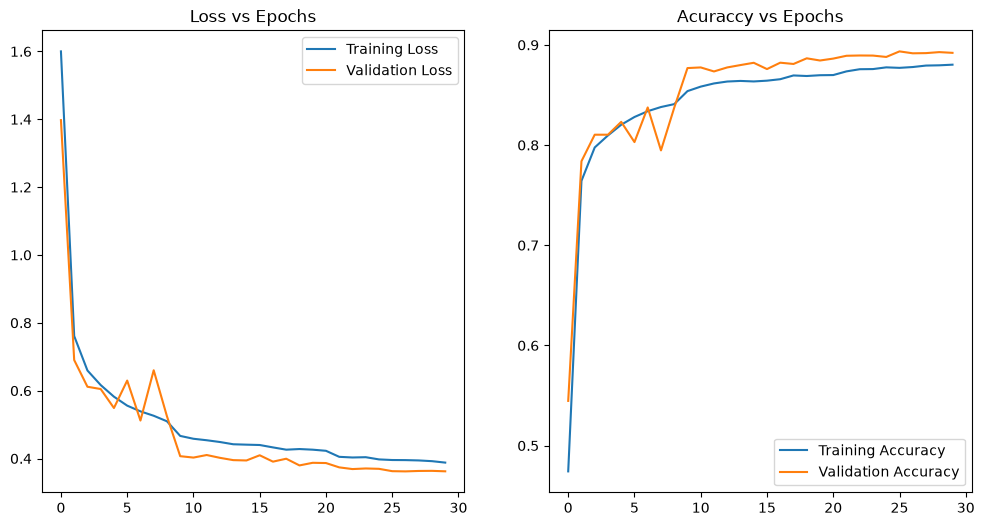

In [22]:
# Same comparison plot as the MLP, this time for the CNN
import matplotlib.pyplot as plt


fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))

ax1.plot(history_cnn.history['loss'], label='Training Loss')
ax1.plot(history_cnn.history['val_loss'], label='Validation Loss')
ax1.set_title('Loss vs Epochs')
ax1.legend()

ax2.plot(history_cnn.history['accuracy'], label='Training Accuracy')
ax2.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
ax2.set_title('Acuraccy vs Epochs')
ax2.legend()

plt.show()

### 6.5 Evaluate on the test set

In [23]:
# Performance on the same 26,032 test images used for the MLP
test_loss, test_acc = model_cnn.evaluate(X_test_gray, y_test, verbose=0)
print(f"Test Loss for CNN model: {test_loss:.4f}")
print(f"Test Accuracy for CNN model: {test_acc:.4f}")

Test Loss for CNN model: 0.4066
Test Accuracy for CNN model: 0.8766


The CNN reaches **87.66% accuracy** on the test set (loss 0.4066), close to 8 points above the MLP with less than a fifth of its parameters — clear evidence that convolutional filters are a much better fit for this kind of image.

## 7. Reload the saved weights and compare predictions

As a sanity check, both models are rebuilt from scratch and reloaded from the checkpoints saved during training, confirming the saved weights reproduce the same test metrics before looking at individual predictions.

In [24]:
# Re-declare both architectures so the saved weights have something to load into
new_model_MLP = Sequential([
    Flatten(input_shape=(32,32,1)),
    Dense(512, activation='relu',
          kernel_regularizer=l2(1e-4),
          kernel_initializer='he_normal'),
    BatchNormalization(),
    Dense(256, activation='relu',
          kernel_regularizer=l2(1e-4),
          kernel_initializer='he_normal'),
    BatchNormalization(),
    Dense(256, activation='relu',
          kernel_regularizer=l2(1e-4),
          kernel_initializer='he_normal'),
    BatchNormalization(),
    Dense(128, activation='relu',kernel_initializer='he_normal'),
    BatchNormalization(),
    Dense(128, activation='relu',
          kernel_initializer='he_normal'),
    BatchNormalization(),
    Dense(10, activation='softmax')
])

new_model_CNN = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu',
           input_shape=(32,32,1)),
    MaxPool2D((2,2)),
    Conv2D(16, (2,2), padding='same', activation='relu'),
    MaxPool2D((2,2)),
    Flatten(),
    Dense(128, activation='relu',kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu',
              kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

In [25]:
# Load the checkpointed weights saved by ModelCheckpoint during training
optimizer= Adam(learning_rate=0.001)

new_model_MLP.load_weights('checkpoint_MLP/MLP_checkpoint.weights.h5')
new_model_MLP.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

new_model_CNN.load_weights('checkpoint_CNN/CNN_checkpoint.weights.h5')
new_model_CNN.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

### 7.1 Confirm the reload

In [26]:
# Both should match the test metrics obtained right after training
test_loss, test_acc = new_model_MLP.evaluate(X_test_gray, y_test, verbose=0)
print(f"Test Loss for MLP model Loaded: {test_loss:.4f}")
print(f"Test Accuracy for MLP model Loaded: {test_acc:.4f}")


test_loss, test_acc = new_model_CNN.evaluate(X_test_gray, y_test, verbose=0)
print(f"Test Loss for CNN model Loaded: {test_loss:.4f}")
print(f"Test Accuracy for CNN model Loaded: {test_acc:.4f}")

Test Loss for MLP model Loaded: 0.8478
Test Accuracy for MLP model Loaded: 0.8006
Test Loss for CNN model Loaded: 0.4066
Test Accuracy for CNN model Loaded: 0.8766


### 7.2 Side-by-side predictions

Five random test images, each with the true label and the probability distribution both models assign to every class.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


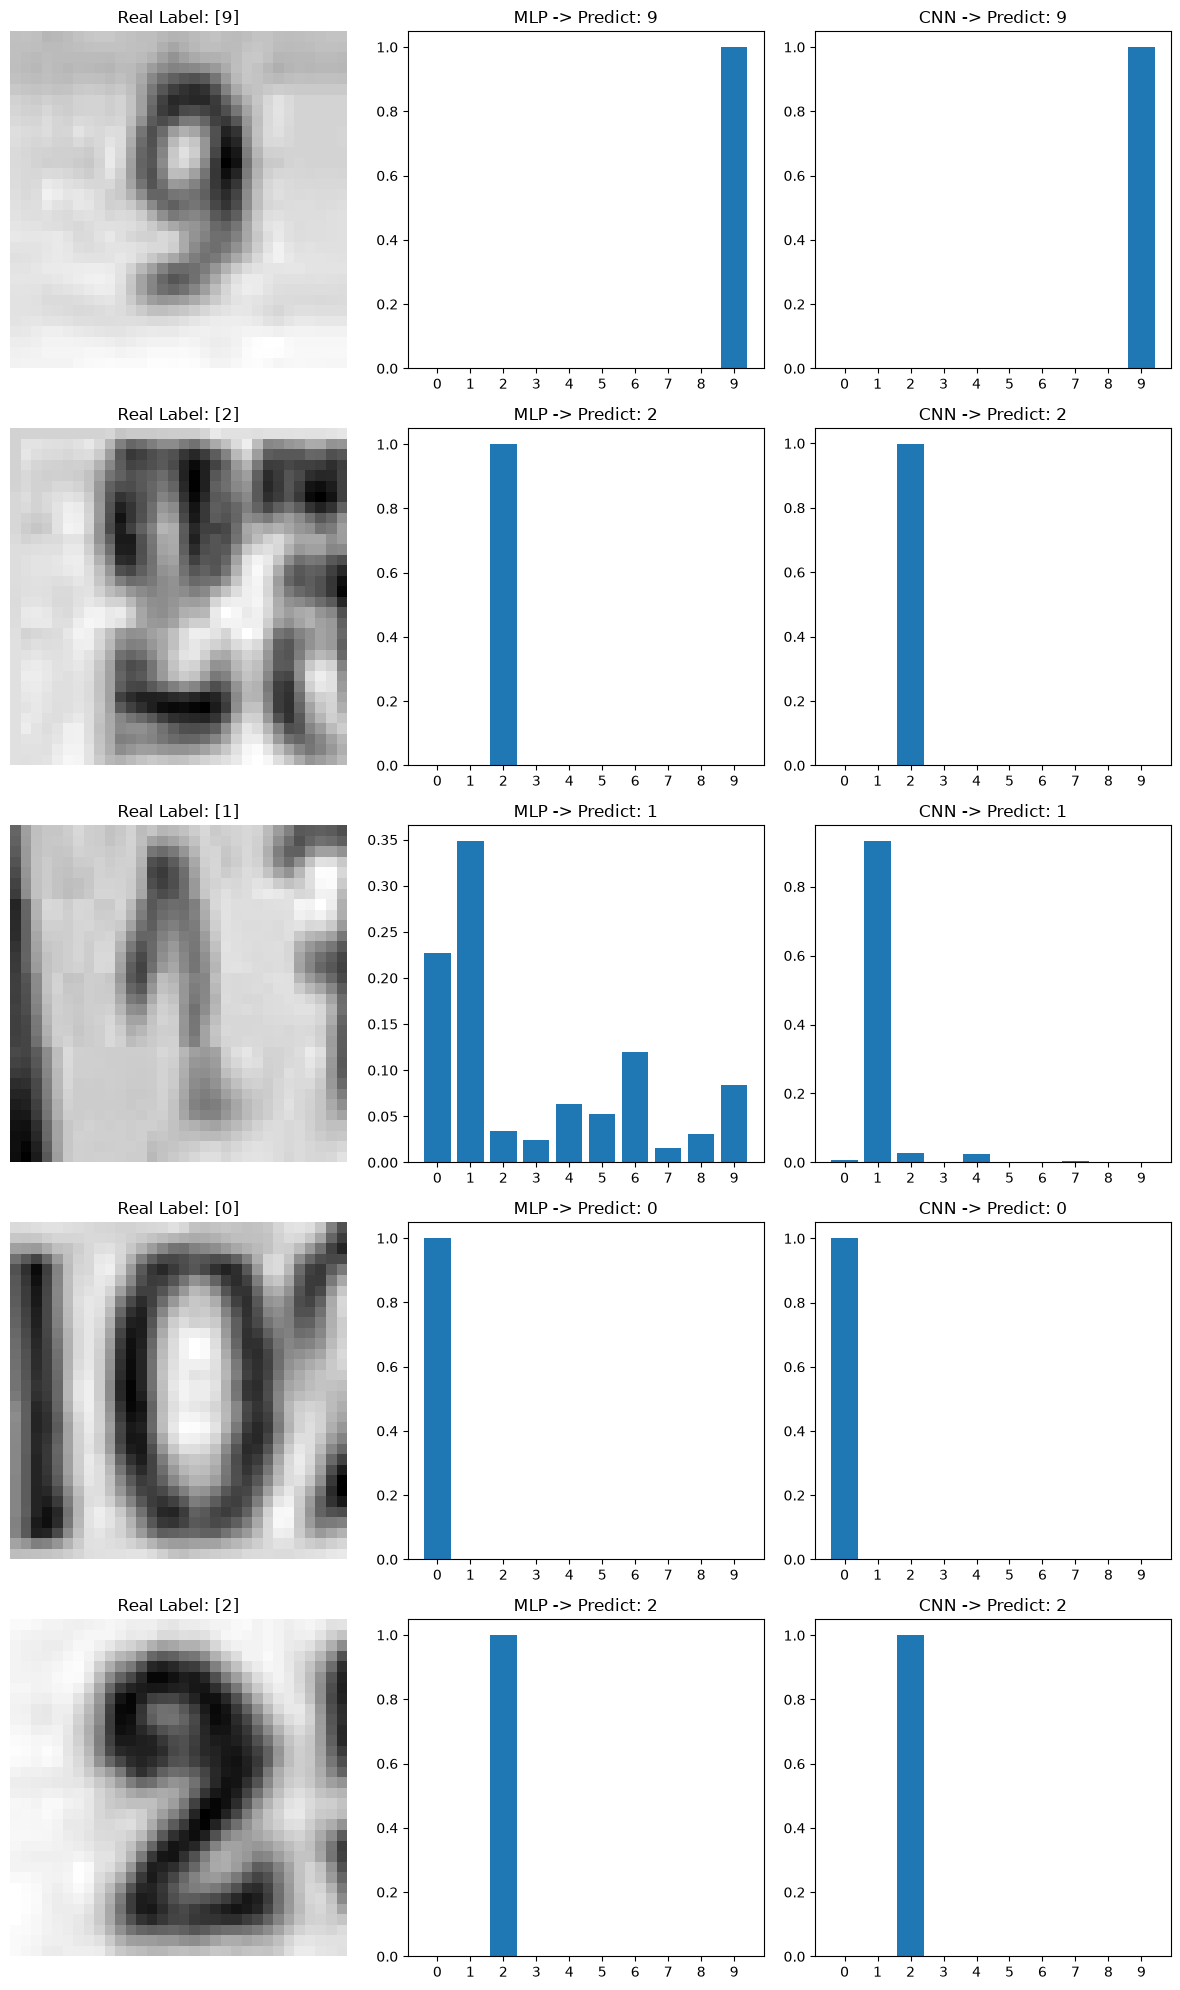

In [28]:
# Five random test images, MLP and CNN predictions plotted next to each other
num_samples = X_test_gray.shape[0] 
idx = np.random.choice(num_samples, size=5, replace=False)

pred_mlp = new_model_MLP.predict(X_test_gray[idx])
pred_cnn = new_model_CNN.predict(X_test_gray[idx])

fig, axes = plt.subplots(5, 3, figsize=(12, 20))

for i, sample_idx in enumerate(idx):

    axes[i, 0].imshow(X_test_gray[sample_idx].squeeze(), cmap='gray')
    axes[i, 0].set_title(f"Real Label: {y_test[sample_idx]}")
    axes[i, 0].axis("off")


    pred_label_mlp = np.argmax(pred_mlp[i])
    axes[i, 1].bar(range(10), pred_mlp[i])
    axes[i, 1].set_title(f"MLP -> Predict: {pred_label_mlp}")
    axes[i, 1].set_xticks(range(10))

    pred_label_cnn = np.argmax(pred_cnn[i])
    axes[i, 2].bar(range(10), pred_cnn[i])
    axes[i, 2].set_title(f"CNN -> Predict: {pred_label_cnn}")
    axes[i, 2].set_xticks(range(10))

plt.tight_layout()
plt.show()

## 8. Summary and results

### What was done

An end-to-end image classification workflow for the SVHN dataset, comparing two TensorFlow 2 / Keras classifiers trained from scratch:

1. **Data loading**: the SVHN `train_32x32.mat` / `test_32x32.mat` files (73,257 training images and 26,032 test images) loaded with `scipy.io.loadmat`.
2. **Preprocessing**: RGB channels averaged into grayscale, axes transposed to the `(N, 32, 32, 1)` format Keras expects, pixel values scaled to `[0, 1]`, and the `10 -> 0` label convention fixed.
3. **Baseline model**: a fully-connected `Sequential` network (512-256-256-128-128 units, batch norm + L2 regularisation), 775,178 trainable parameters.
4. **Convolutional model**: two `Conv2D` + `MaxPooling2D` blocks (32 and 16 filters) followed by a small dense head with dropout, 151,898 trainable parameters.
5. **Training**: both models trained for up to 30 epochs, batch size 128, a 15% validation split and the same three callbacks (`ModelCheckpoint`, `EarlyStopping`, `ReduceLROnPlateau`).
6. **Evaluation**: measured on the 26,032 held-out test images, plus a reload-from-checkpoint sanity check and a side-by-side comparison of individual predictions.

### Results

| Model | Trainable params | Train accuracy | Val accuracy | Test accuracy | Test loss |
|-------|------------------:|----------------:|---------------:|----------------:|-----------:|
| MLP   | 775,178 | 87.19% | 82.50% | **80.06%** | 0.8478 |
| CNN   | 151,898 | 88.03% | 89.21% | **87.66%** | 0.4066 |

Both models trained the full 30 epochs without `EarlyStopping` triggering; `ReduceLROnPlateau` fired several times on each, gradually taking the learning rate down as validation loss flattened out.

### Conclusions

- **Convolutions win by a wide margin.** With roughly a fifth of the parameters of the MLP, the CNN scores about 7.6 points higher on the test set. Treating the image as a flat vector of pixels, like the MLP does, throws away exactly the spatial structure that convolutional filters are built to exploit — and SVHN, with its cluttered, real-world backgrounds, punishes that choice more than a clean dataset like MNIST would.
- **The MLP overfits more.** Its 87.19% training accuracy is close to the CNN's 88.03%, but its test accuracy falls 2.44 points short of its own validation accuracy, a bigger generalisation gap than the CNN shows (89.21% val vs 87.66% test, a 1.55 point gap).
- **Checkpointing paid off.** Reloading each model from its saved `.weights.h5` file reproduces the exact same test metrics, confirming `ModelCheckpoint` kept the best-performing weights rather than the last epoch's.

### Possible improvements

- Train on the RGB images directly instead of converting to grayscale, since colour can help separate a digit from its background.
- Add data augmentation (small rotations, translations, brightness jitter) to help both models generalise to the variety of real-world photos in SVHN.
- Try a deeper CNN with more filters, the usual way to close more of the remaining gap to clean-dataset accuracy.
- Build a confusion matrix to see which digits the CNN still confuses most often.